# Actor Interaction Network
Ce notebook construit un graphe d'interactions entre acteurs (`Actor1Name`, `Actor2Name`) et affiche une visualisation interactive via Plotly.

In [15]:
from pathlib import Path
import sys
import pandas as pd
project_root = Path.cwd()
if not (project_root / 'data').exists():
    project_root = project_root.parent
sys.path.append(str(project_root))
from src.visualization.network_graph import build_actor_graph, graph_to_plotly
DATA_PATH = project_root / 'data/processed/gdelt_benin_clean.csv'
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Cannot find data file: {DATA_PATH}')
df = pd.read_csv(DATA_PATH)
print('Loaded', len(df), 'rows')

Loaded 6647 rows


In [16]:
G = build_actor_graph(df, actor1_col='Actor1Name', actor2_col='Actor2Name', min_edge_weight=2)
print('Graph nodes:', G.number_of_nodes(), 'edges:', G.number_of_edges())

Graph nodes: 449 edges: 333


In [19]:
import plotly.io as pio
try:
    import nbformat
    print('nbformat version:', nbformat.__version__)
except Exception as e:
    print('nbformat import error:', e)
print('plotly renderer default before:', pio.renderers.default)
# Try to set a notebook-friendly renderer (ignore failures)
for candidate in ('notebook_connected','notebook','iframe_connected','iframe','vscode','browser'):
    try:
        pio.renderers.default = candidate
        print('set renderer to', candidate)
        break
    except Exception as e:
        print('cannot set renderer', candidate, e)
print('plotly renderer default after:', pio.renderers.default)

nbformat version: 5.10.4
plotly renderer default before: vscode
set renderer to notebook_connected
plotly renderer default after: notebook_connected


Saved image to /home/appolinaire/projects/benin-insights-challenge-team2/reports/actor_network.png


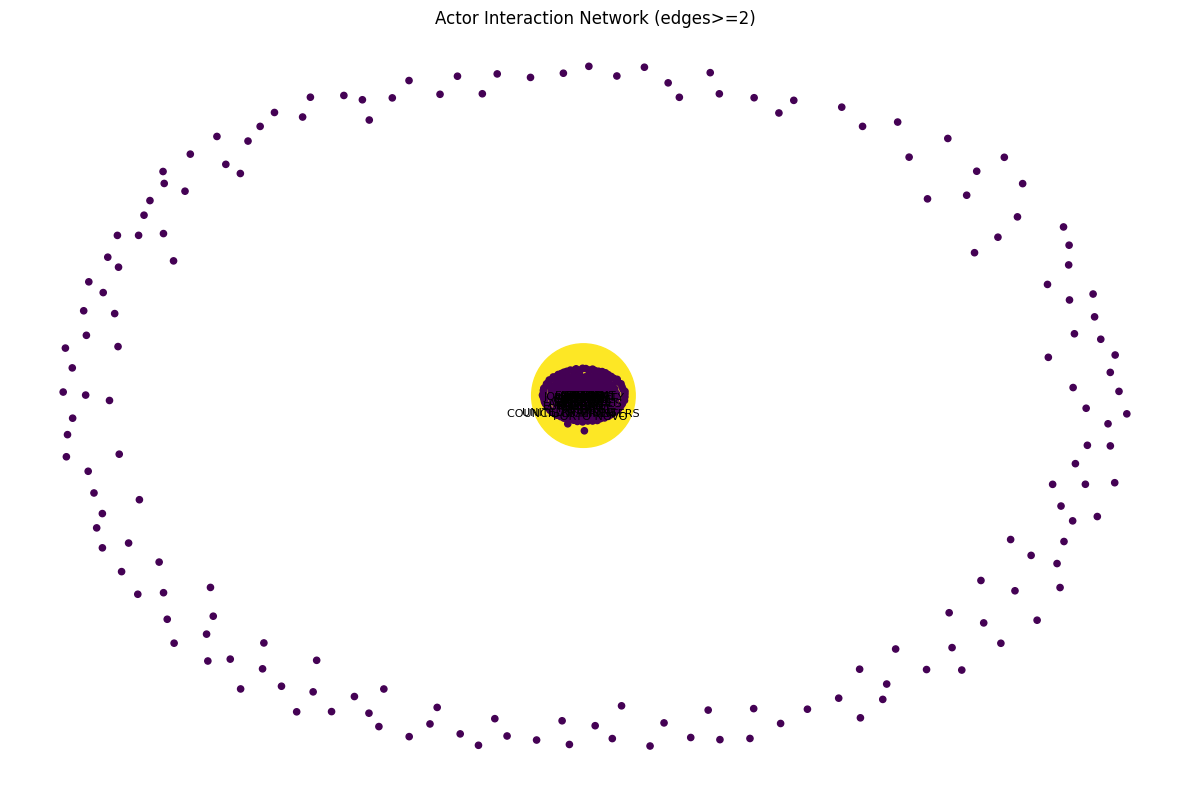

In [24]:
# Render a static image of the network using matplotlib + networkx
import matplotlib.pyplot as plt
import networkx as nx
from math import ceil
# layout
pos = nx.spring_layout(G, seed=42)
# prepare node sizes and colors by degree
degrees = dict(G.degree())
node_sizes = [max(20, degrees.get(n, 0) * 20) for n in G.nodes()]
node_colors = [degrees.get(n, 0) for n in G.nodes()]
plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.viridis)
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.7)
# labels for highest-degree nodes only to avoid clutter
top_n = 30
top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:top_n]
labels = {n: n for n, _ in top_nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=8)
plt.title('Actor Interaction Network (edges>=2)')
plt.axis('off')
plt.tight_layout()
# save to reports and display inline
OUT = project_root / 'reports'
OUT.mkdir(parents=True, exist_ok=True)
out_png = OUT / 'actor_network.png'
plt.savefig(out_png, dpi=150)
print('Saved image to', out_png)
plt.show()

Notes:
- Ajuster `min_edge_weight` pour contrôler la densité du graphe.
- Pour de grands graphes, augmenter `min_edge_weight` ou agréger par pays/rôle.
- Intégration Streamlit: utilisez `st.plotly_chart(fig)` dans une page `dashboard/pages/` pour l'afficher dans l'app.